In [3]:
import os
HF_TOKEN = os.environ.get("HF_TOKEN")

In [4]:
from transformer_lens.model_bridge import TransformerBridge

bridge = TransformerBridge.boot_transformers("gpt2", device="cpu")
logits, cache = bridge.run_with_cache("Hello World")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 14270.60it/s]


In [5]:
print(logits)
print(cache)

tensor([[[-43.4317, -39.8364, -43.0660,  ..., -54.0877, -54.3451, -42.3644],
         [-61.0648, -68.0792, -72.3322,  ..., -73.9382, -74.3353, -68.3130],
         [-43.5787, -50.2104, -52.9083,  ..., -57.6991, -57.5098, -49.6761]]],
       grad_fn=<ViewBackward0>)
ActivationCache with keys ['embed.hook_in', 'embed.hook_out', 'hook_embed', 'pos_embed.hook_in', 'pos_embed.hook_out', 'hook_pos_embed', 'blocks.0.hook_in', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_in', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.ln1.hook_out', 'blocks.0.attn.hook_in', 'blocks.0.attn.q.hook_in', 'blocks.0.attn.q.hook_out', 'blocks.0.attn.hook_q', 'blocks.0.attn.k.hook_in', 'blocks.0.attn.k.hook_out', 'blocks.0.attn.hook_k', 'blocks.0.attn.v.hook_in', 'blocks.0.attn.v.hook_out', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.o.hook_in', 'blocks.0.attn.hook_z', 'blocks.0.attn.o.hook_out', 'blocks.0.attn.hook_hidden_states', 'b

# 모델이 다음 토큰으로 뭘 예측하는지 확인

In [7]:
import torch
import pandas as pd

prompt = "Hello World"

tokens = bridge.to_tokens(prompt)
str_tokens = bridge.to_str_tokens(prompt)

logits, cache = bridge.run_with_cache(tokens, remove_batch_dim=True)

print(tokens)
print(str_tokens)
print(logits.shape)

tensor([[50256, 15496,  2159]])
['<|endoftext|>', 'Hello', ' World']
torch.Size([1, 3, 50257])


In [10]:
next_logits = logits[0, -1]
topk = torch.topk(next_logits, k=10)

for token_id, logit in zip(topk.indices, topk.values):
    print(repr(bridge.to_string(token_id.item())), float(logit))

',' -43.47295379638672
'!' -43.57866287231445
'\n' -44.716732025146484
'.' -44.834869384765625
' of' -46.268394470214844
' !' -46.80788040161133
' and' -46.98529815673828
"'s" -47.05792999267578
'\n\n' -47.312255859375
':' -47.431617736816406


/var/folders/mh/1w84fr7s5kxcwc2l24qrjjwc0000gn/T/ipykernel_14478/588846368.py:5: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:839.)
  print(repr(bridge.to_string(token_id.item())), float(logit))


# cache에 들어있는 activation 이름과 shape 보기

In [12]:
for name, act in cache.items():
    if name.startswith(("embed", "pos_embed", "blocks.0", "ln_final")):
        print(name, tuple(act.shape))

embed.hook_in (3,)
embed.hook_out (3, 768)
pos_embed.hook_in (3,)
pos_embed.hook_out (3, 768)
blocks.0.hook_in (3, 768)
blocks.0.hook_resid_pre (3, 768)
blocks.0.ln1.hook_in (3, 768)
blocks.0.ln1.hook_scale (3, 1)
blocks.0.ln1.hook_normalized (3, 768)
blocks.0.ln1.hook_out (3, 768)
blocks.0.attn.hook_in (3, 768)
blocks.0.attn.q.hook_in (3, 768)
blocks.0.attn.q.hook_out (3, 12, 64)
blocks.0.attn.hook_q (3, 12, 64)
blocks.0.attn.k.hook_in (3, 768)
blocks.0.attn.k.hook_out (3, 12, 64)
blocks.0.attn.hook_k (3, 12, 64)
blocks.0.attn.v.hook_in (3, 768)
blocks.0.attn.v.hook_out (3, 12, 64)
blocks.0.attn.hook_v (3, 12, 64)
blocks.0.attn.hook_attn_scores (12, 3, 3)
blocks.0.attn.hook_pattern (12, 3, 3)
blocks.0.attn.o.hook_in (3, 12, 64)
blocks.0.attn.hook_z (3, 12, 64)
blocks.0.attn.o.hook_out (3, 768)
blocks.0.attn.hook_hidden_states (3, 768)
blocks.0.attn.hook_out (3, 768)
blocks.0.hook_attn_out (3, 768)
blocks.0.ln2.hook_in (3, 768)
blocks.0.hook_resid_mid (3, 768)
blocks.0.ln2.hook_scale (

In [13]:
cache["embed.hook_out"].shape
cache["blocks.0.hook_in"].shape
cache["blocks.0.attn.hook_pattern"].shape
cache["blocks.0.hook_out"].shape

torch.Size([3, 768])

# attention pattern 하나 시각화하기

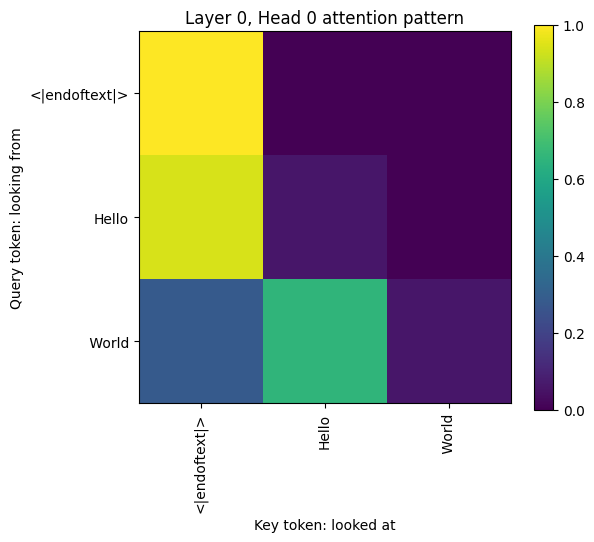

In [15]:
import matplotlib.pyplot as plt

layer = 0
head = 0

pattern = cache[f"blocks.{layer}.attn.hook_pattern"]

# remove_batch_dim=True면 보통 [n_heads, pos, pos]
# 혹시 batch dim이 남아있으면 제거
if pattern.ndim == 4:
    pattern = pattern[0]

attn = pattern[head].detach().cpu()

plt.figure(figsize=(6, 5))
plt.imshow(attn)
plt.xticks(range(len(str_tokens)), str_tokens, rotation=90)
plt.yticks(range(len(str_tokens)), str_tokens)
plt.xlabel("Key token: looked at")
plt.ylabel("Query token: looking from")
plt.title(f"Layer {layer}, Head {head} attention pattern")
plt.colorbar()
plt.show()

In [16]:
for layer in range(12):
    pattern = cache[f"blocks.{layer}.attn.hook_pattern"]
    print(layer, pattern.shape)

0 torch.Size([12, 3, 3])
1 torch.Size([12, 3, 3])
2 torch.Size([12, 3, 3])
3 torch.Size([12, 3, 3])
4 torch.Size([12, 3, 3])
5 torch.Size([12, 3, 3])
6 torch.Size([12, 3, 3])
7 torch.Size([12, 3, 3])
8 torch.Size([12, 3, 3])
9 torch.Size([12, 3, 3])
10 torch.Size([12, 3, 3])
11 torch.Size([12, 3, 3])


# 첫 번째 실험: activation을 지워보기, ablation

In [17]:
def zero_ablate_hook(act, hook):
    return torch.zeros_like(act)

clean_logits = bridge(prompt)

ablated_logits = bridge.run_with_hooks(
    prompt,
    fwd_hooks=[
        ("blocks.0.attn.hook_out", zero_ablate_hook)
    ]
)

clean_top = torch.topk(clean_logits[0, -1], 5)
ablated_top = torch.topk(ablated_logits[0, -1], 5)

print("Clean:")
for tid, val in zip(clean_top.indices, clean_top.values):
    print(repr(bridge.to_string(tid.item())), float(val))

print("\nAblated:")
for tid, val in zip(ablated_top.indices, ablated_top.values):
    print(repr(bridge.to_string(tid.item())), float(val))

Clean:
',' -43.47295379638672
'!' -43.57866287231445
'\n' -44.716732025146484
'.' -44.834869384765625
' of' -46.268394470214844

Ablated:
'!' -53.480674743652344
' of' -53.8032112121582
'.' -54.197784423828125
'\n' -54.21002960205078
',' -54.70823287963867


# 두 번째 실험: clean/corrupt prompt로 activation patching

In [18]:
clean_prompt = "After John and Mary went to the store, Mary gave a bottle of milk to"
corrupt_prompt = "After John and Mary went to the store, John gave a bottle of milk to"

clean_tokens = bridge.to_tokens(clean_prompt)
corrupt_tokens = bridge.to_tokens(corrupt_prompt)

john_id = bridge.to_single_token(" John")
mary_id = bridge.to_single_token(" Mary")

def logit_diff(logits):
    return logits[0, -1, john_id] - logits[0, -1, mary_id]

clean_logits, clean_cache = bridge.run_with_cache(clean_tokens, remove_batch_dim=False)
corrupt_logits = bridge(corrupt_tokens)

print("clean logit diff:", float(logit_diff(clean_logits)))
print("corrupt logit diff:", float(logit_diff(corrupt_logits)))

clean logit diff: 4.276359558105469
corrupt logit diff: -2.73760986328125


In [19]:
from functools import partial

def patch_resid_hook(resid, hook, position):
    clean_resid = clean_cache[hook.name]
    resid[:, position, :] = clean_resid[:, position, :]
    return resid

layer = 7
position = -1  # final token position

patched_logits = bridge.run_with_hooks(
    corrupt_tokens,
    fwd_hooks=[
        (
            f"blocks.{layer}.hook_in",
            partial(patch_resid_hook, position=position)
        )
    ]
)

print("patched logit diff:", float(logit_diff(patched_logits)))

patched logit diff: -2.6061859130859375


In [21]:
prompt = "The capital of France is"
tokens = bridge.to_tokens(prompt)
str_tokens = bridge.to_str_tokens(prompt)
logits, cache = bridge.run_with_cache(prompt)

In [22]:
tokens

tensor([[50256,   464,  3139,   286,  4881,   318]])

In [23]:
str_tokens

['<|endoftext|>', 'The', ' capital', ' of', ' France', ' is']

In [24]:
logits

tensor([[[ -43.4317,  -39.8364,  -43.0660,  ...,  -54.0877,  -54.3451,
           -42.3644],
         [ -74.7909,  -72.5893,  -74.1252,  ...,  -74.4170,  -77.7809,
           -72.4503],
         [ -76.3973,  -76.1667,  -83.4326,  ...,  -83.5390,  -79.5915,
           -76.9084],
         [ -84.9205,  -83.3500,  -85.9710,  ...,  -88.5312,  -90.1416,
           -83.9883],
         [ -88.0450,  -88.8253,  -92.6095,  ...,  -99.4914,  -93.3175,
           -89.3813],
         [-111.7180, -110.7893, -114.9884,  ..., -120.0351, -114.6412,
          -112.8390]]], grad_fn=<ViewBackward0>)

In [26]:
cache

ActivationCache with keys ['embed.hook_in', 'embed.hook_out', 'hook_embed', 'pos_embed.hook_in', 'pos_embed.hook_out', 'hook_pos_embed', 'blocks.0.hook_in', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_in', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.ln1.hook_out', 'blocks.0.attn.hook_in', 'blocks.0.attn.q.hook_in', 'blocks.0.attn.q.hook_out', 'blocks.0.attn.hook_q', 'blocks.0.attn.k.hook_in', 'blocks.0.attn.k.hook_out', 'blocks.0.attn.hook_k', 'blocks.0.attn.v.hook_in', 'blocks.0.attn.v.hook_out', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.o.hook_in', 'blocks.0.attn.hook_z', 'blocks.0.attn.o.hook_out', 'blocks.0.attn.hook_hidden_states', 'blocks.0.attn.hook_out', 'blocks.0.hook_attn_out', 'blocks.0.ln2.hook_in', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.ln2.hook_out', 'blocks.0.mlp.hook_in', 'blocks.0.hook_mlp_in', 'blocks.0.mlp.in.hook_in', 'bloc